In [56]:
import os
import yaml
import numpy as np

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

import ml_collections
from clu import checkpoint


from molnet import utils, train_state, train
from molnet.data import input_pipeline_seg, input_pipeline_fdbm
from molnet.models import create_model
from configs import root_dirs
from analyses import make_predictions

from typing import Tuple

INDEX_TO_SYMBOL = {
    0: 'background',
    1: 'H', 2: '(He)',
    3: '(Li)', 4: '(Be)', 5: '(B)', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 10: 'Ne',
    11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 16: 'S', 17: 'Cl', 18: 'Ar',
    19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti', 23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe', 27: 'Co', 28: 'Ni', 29: 'Cu', 30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se', 35: 'Br',
}
INDEX_TO_SYMBOL_SHORT = {
    0: "background",
    1: "H", 2: "C", 3: "N", 4: "O", 5: "F",
    6: "Si", 7: "P", 8: "S", 9: "Cl", 10: "Br",
}

In [2]:
#workdir = "/u/79/kurkil1/unix/work/molnet/runs/bf16-augs-rebias-adam-3e-4-z10-reverse-z/"
#workdir = "/u/79/kurkil1/unix/work/molnet/runs/bf16-augs-rebias-adam-3e-4-z20-interp/"
workdir = "/u/79/kurkil1/unix/work/molnet/runs/segmentation/segment-fdbm-adam-3e-4-ce/"

In [4]:
def load_from_workdir(
    workdir: str,
    return_attention: bool
):
    # Load the model config
    with open(os.path.join(workdir, "config.yaml"), "rt") as f:
        config = yaml.unsafe_load(f)
    config = ml_collections.ConfigDict(config)
    #config.root_dir = root_dirs.get_root_dir("afms_rebias")
    config.root_dir = "/u/79/kurkil1/unix/work/molnet/data/SIN-AFM-FDBM-tf"
    config.model.return_attention_maps = return_attention

    print(config)

    # Create the model
    model = create_model(config.model)

    checkpoint_dir = os.path.join(workdir, "checkpoints")
    ckpt = checkpoint.Checkpoint(checkpoint_dir)

    apply_fn = model.apply
    tx = utils.create_optimizer(config)
    restored_state = ckpt.restore(state=None)['state']

    # Load the model state
    state = train_state.EvaluationState.create(
        apply_fn=apply_fn,
        params=restored_state['params'],
        batch_stats=restored_state['batch_stats'],
        tx=tx,
    )
    state = jax.tree_util.tree_map(jnp.asarray, state)

    return state, config

In [5]:
state, config = load_from_workdir(
    workdir=workdir,
    return_attention=False
)

batch_size: 12
cutout_probs:
- 0.5
- 0.3
- 0.1
- 0.05
- 0.05
dataset: SIN-AFM-FDBM-tf
debug: false
eval_every_steps: 2000
gaussian_factor: 1.0
interpolate_input_z: null
learning_rate: 0.0003
learning_rate_schedule: constant
learning_rate_schedule_kwargs:
  decay_steps: 50000
  init_value: 0.0003
  peak_value: 0.0006
  warmup_steps: 2000
log_every_steps: 100
loss_fn: cross_entropy
max_atoms: 54
max_shift_per_slice: 0.02
model:
  attention_activation: sigmoid
  attention_channels:
  - 16
  - 32
  - 64
  - 64
  - 128
  conv_activation: relu
  decoder_channels:
  - 256
  - 128
  - 64
  - 32
  - 16
  decoder_kernel_size:
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  dtype: bfloat16
  encoder_channels:
  - 16
  - 32
  - 64
  - 128
  - 256
  encoder_kernel_size:
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  model_name: Attention-UNet
  output_

2025-03-03 11:23:08.413933: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
rng = jax.random.PRNGKey(0)
datarng, rng = jax.random.split(rng)
#with config.unlocked():
    #config.z_cutoff = 1.0
    #config.interpolate_z = None
    #config.target_z_cutoff = 1.0
    #config.train_molecules = (0, 80000)
    #config.val_molecules = (80000, 100000)
    #config.max_shift_per_slice = 0.02

ds = input_pipeline_fdbm.get_datasets(
    config
)['val']

batch = next(ds)

for k, v in batch.items():
    print(k, v.shape)

[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.data.experimental.DistributedSnapshotMetadata: 1:1: Invalid control characters encountered in text.
[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.data.experimental.DistributedSnapshotMetadata: 1:3: Expected identifier, got: 16953204235756542563
[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.data.experimental.DistributedSnapshotMetadata: 1:1: Invalid control characters encountered in text.
[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.data.experimental.DistributedSnapshotMetadata: 1:3: Expected identifier, got: 11686738426939340915
[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing 

images (12, 160, 160, 10, 1)
xyz (12, 54, 5)
sw (12, 2, 3)
atom_map (12, 160, 160, 10)


In [8]:
@jax.jit
def predict(
    state,
    batch,
):
    inputs, targets = batch['images'], batch['atom_map']
    preds = state.apply_fn(
        {'params': state.params, 'batch_stats': state.batch_stats},
        inputs,
        training=False,
    )
    return inputs, targets, preds, batch["xyz"]

In [9]:
batch = next(ds)

In [10]:
inputs, targets, preds, xyz = predict(state, batch)

2025-03-03 11:23:58.225431: E external/xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (bf16[12,128,160,160,10]{4,3,2,1,0}, u8[0]{0}) custom-call(bf16[12,16,160,160,10]{4,3,2,1,0}, bf16[128,16,3,3,3]{4,3,2,1,0}, bf16[128]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-03-03 11:24:01.751900: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 4.526572005s
Trying algorithm eng0{} for conv (bf16[12,128,160,160,10]{4,3,2,1,0}, u8[0]{0}) custom-call(bf16[12,16,160,160,10]{4,3,2,1,0}, bf16[128,16,3,3,3]{4,3,2,1,0}, bf16[128]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target=

In [12]:
print(targets.shape, preds.shape)

(12, 160, 160, 10) (12, 160, 160, 10, 36)


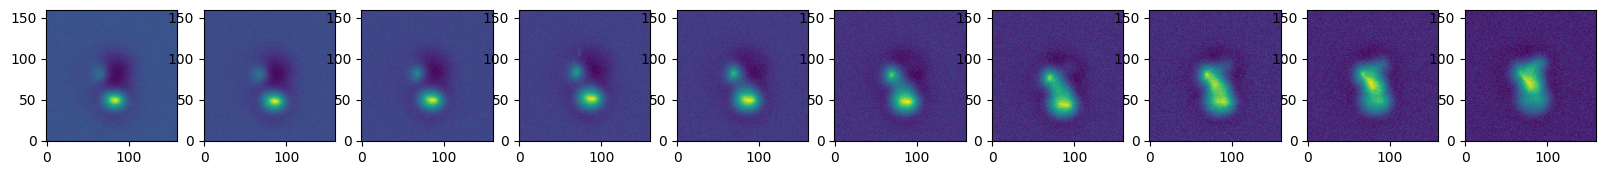

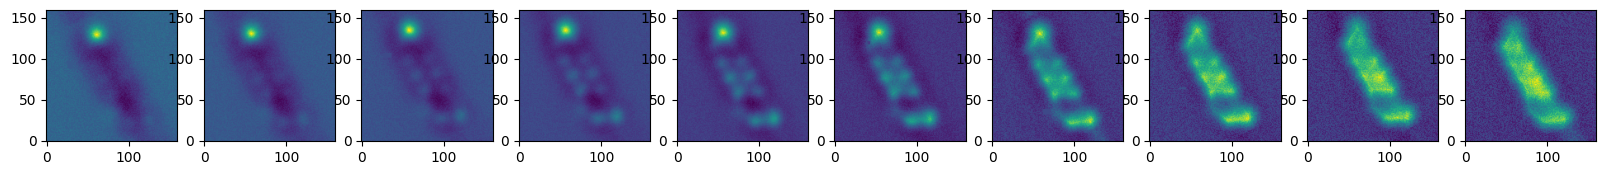

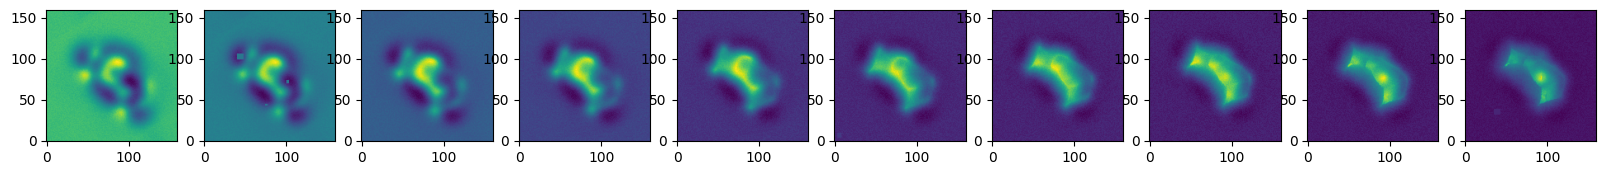

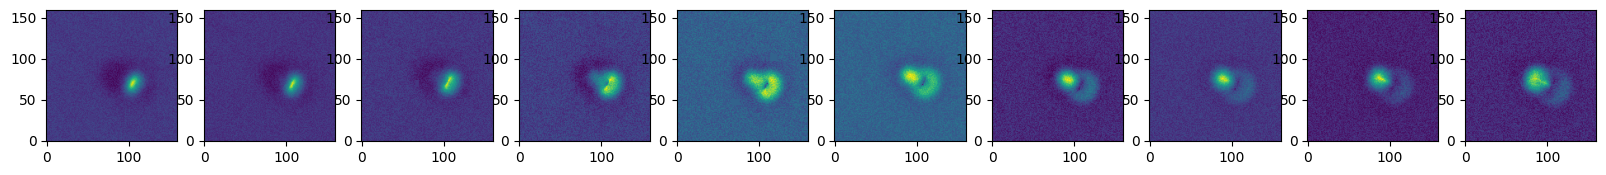

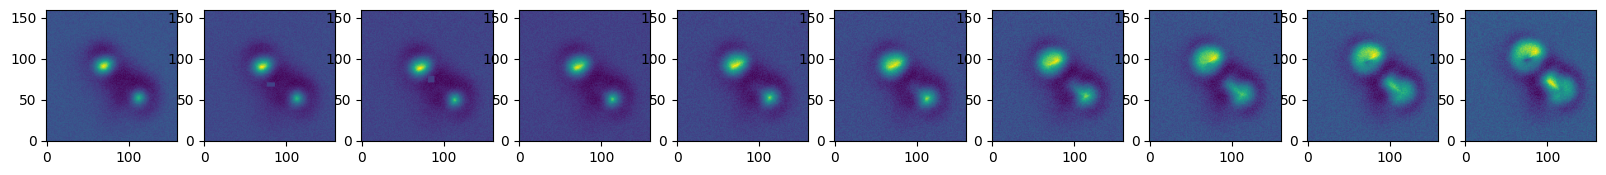

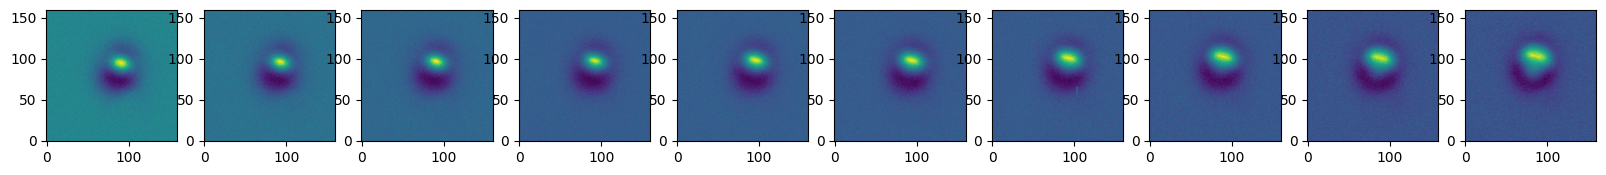

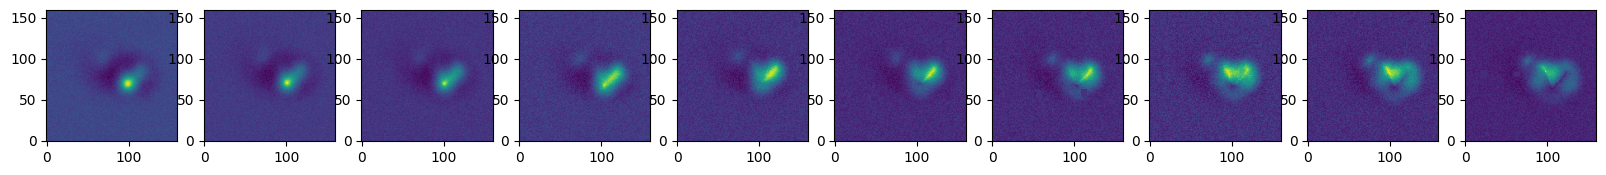

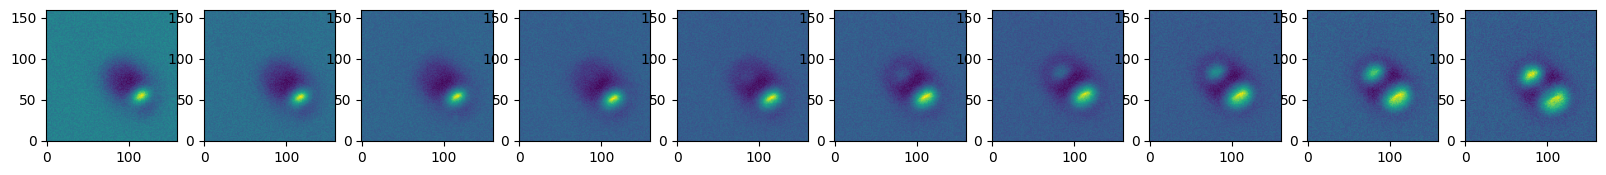

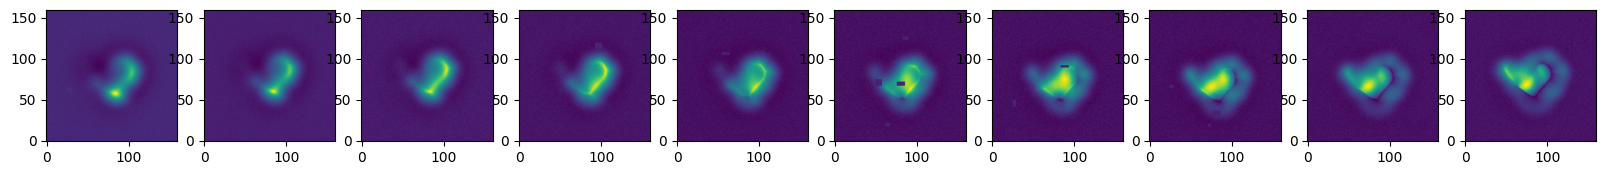

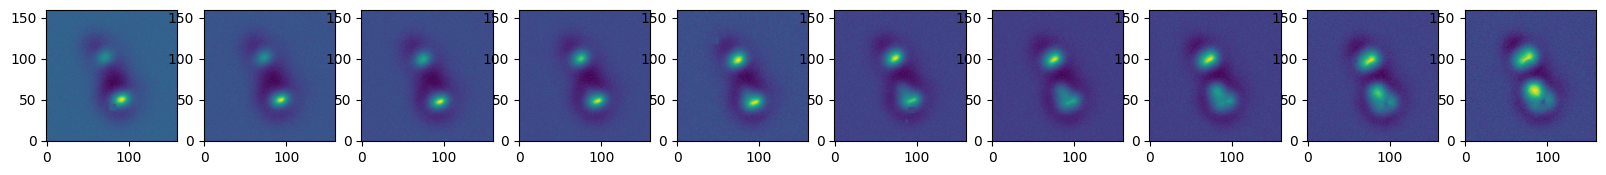

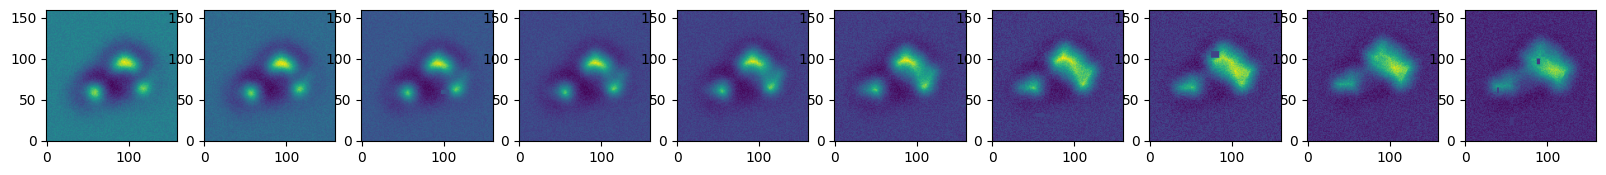

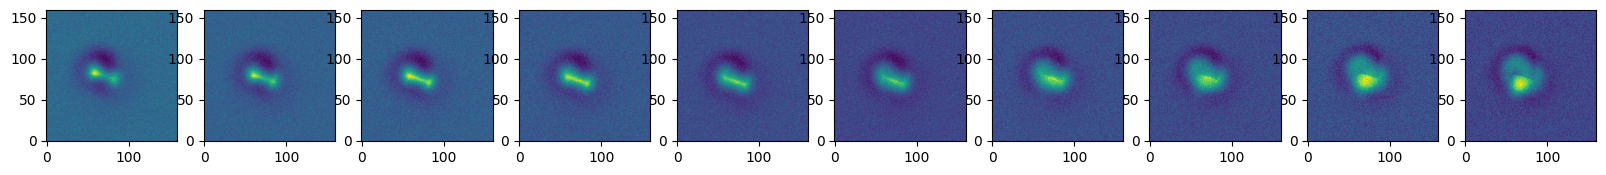

In [13]:
for i in range(inputs.shape[0]):
    fig = plt.figure(figsize=(20, 2))
    for z in range(preds.shape[-2]):
        ax = plt.subplot(1, 10, z+1)
        ax.imshow(inputs[i, ..., z, 0], origin='lower')

    plt.show()

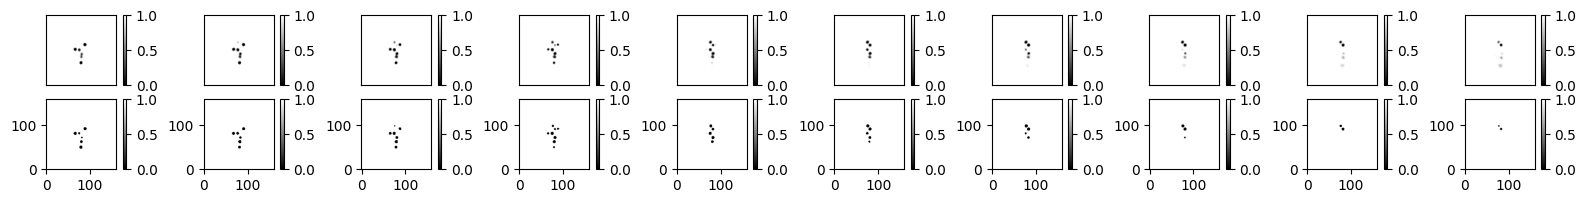

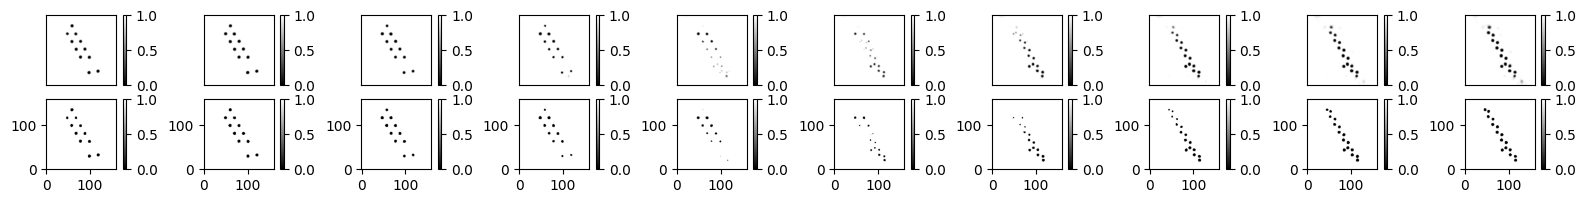

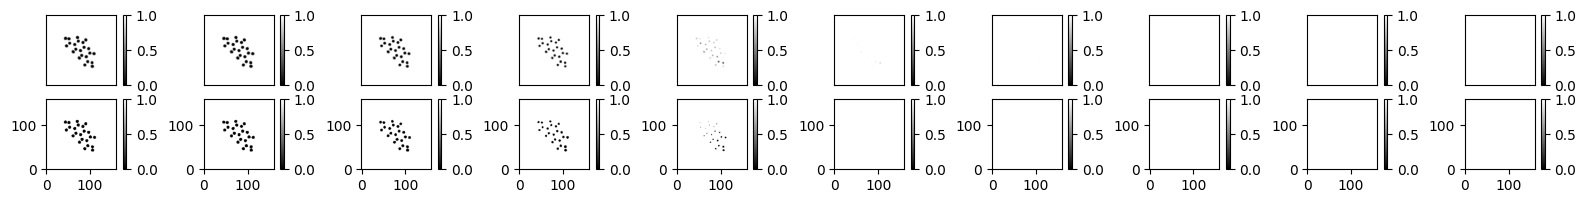

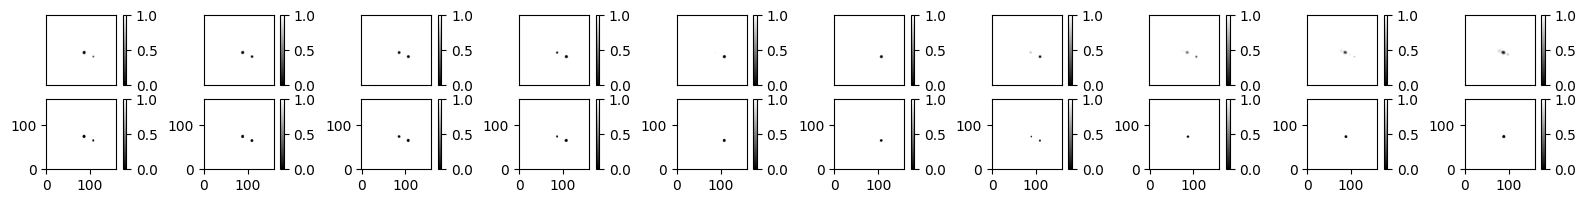

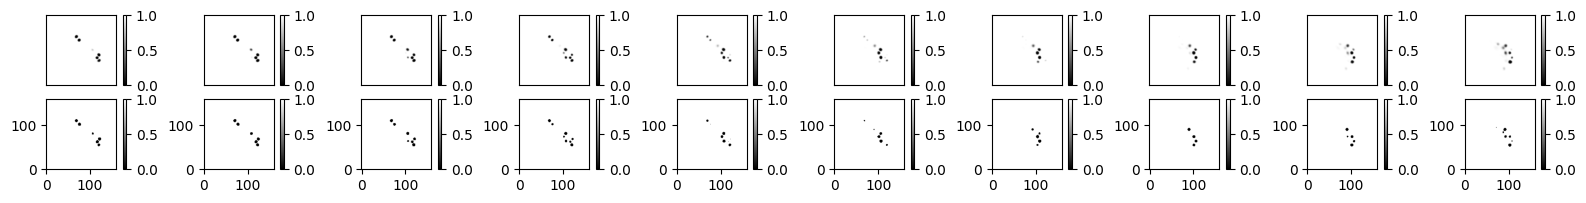

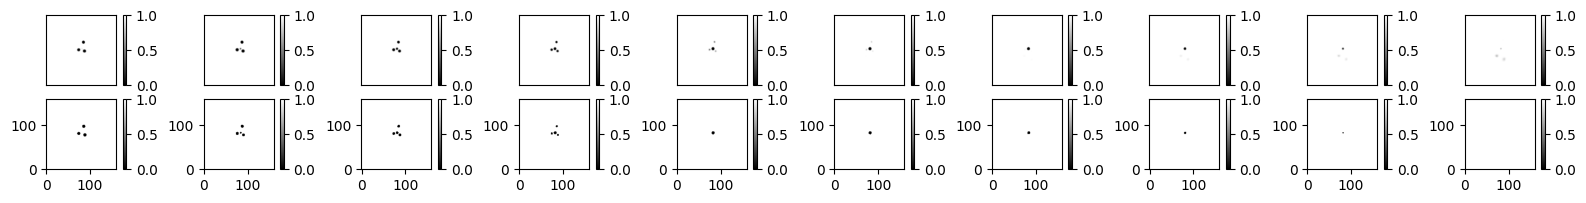

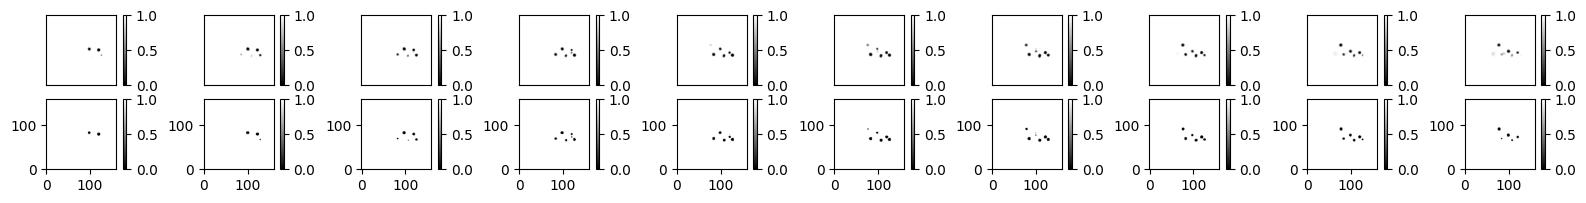

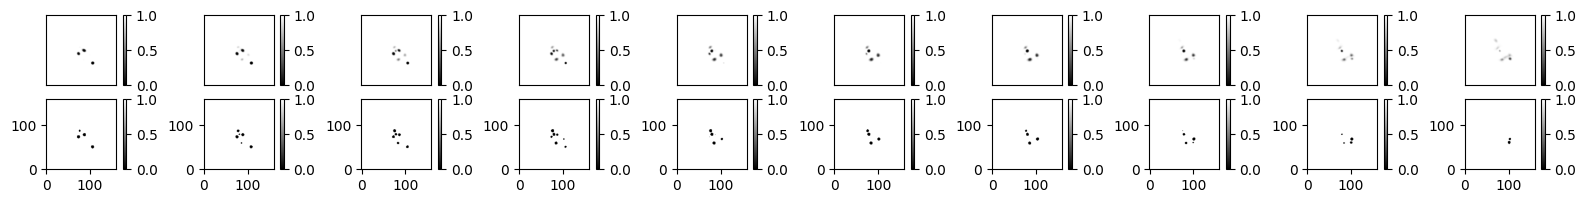

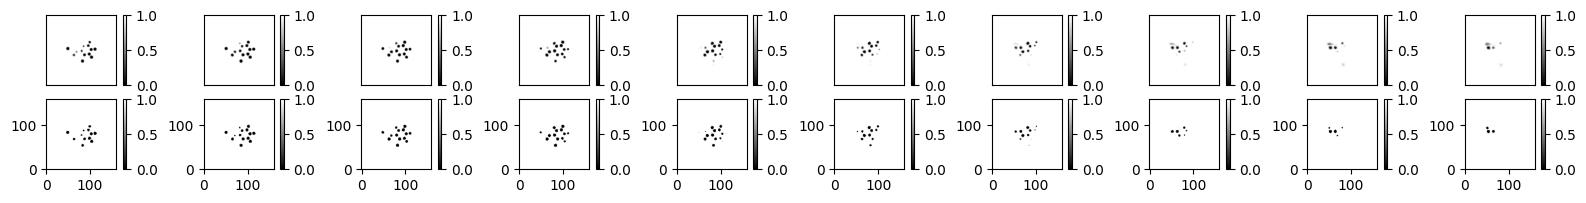

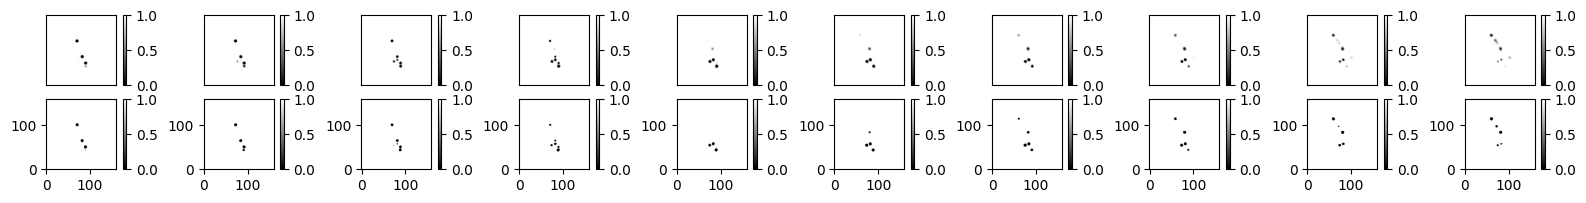

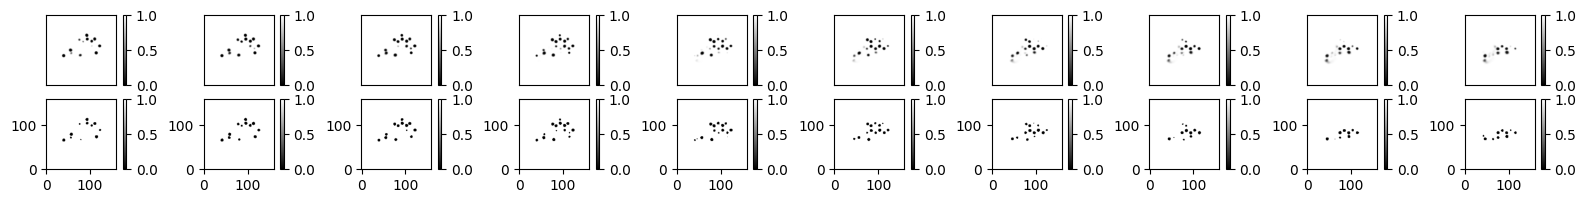

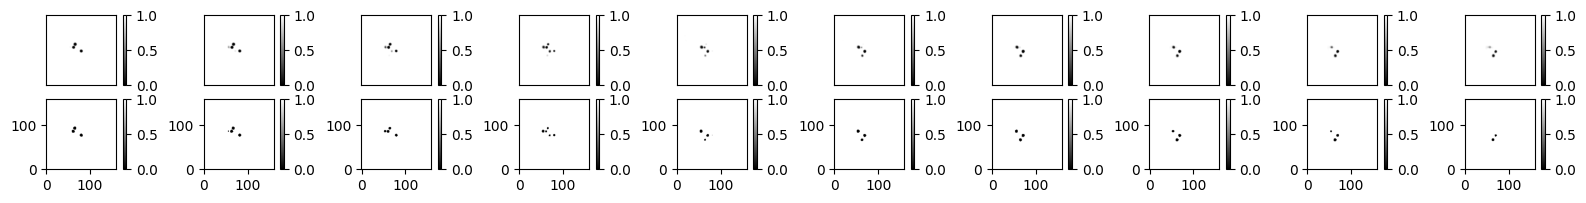

In [21]:
for i in range(inputs.shape[0]):
    fig = plt.figure(figsize=(20, 2))
    pred_softmax = jax.nn.softmax(preds[i], axis=-1)
    for z in range(preds.shape[-2]):
        ax = plt.subplot(2, 10, z+1)
        im = ax.imshow(pred_softmax[..., z, 0], cmap="gray", origin='lower', vmin=0, vmax=1)
        plt.colorbar(im)
        ax.set_xticks([])
        ax.set_yticks([])

        ax = plt.subplot(2, 10, z+11)
        im = ax.imshow(targets[i, ..., z]==0, cmap="gray", origin='lower', vmin=0, vmax=1)
        plt.colorbar(im)


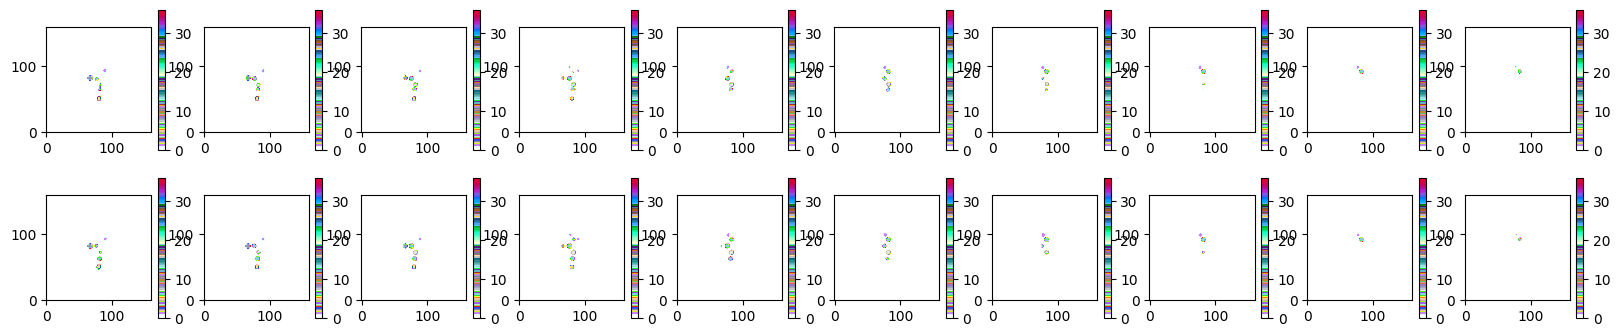

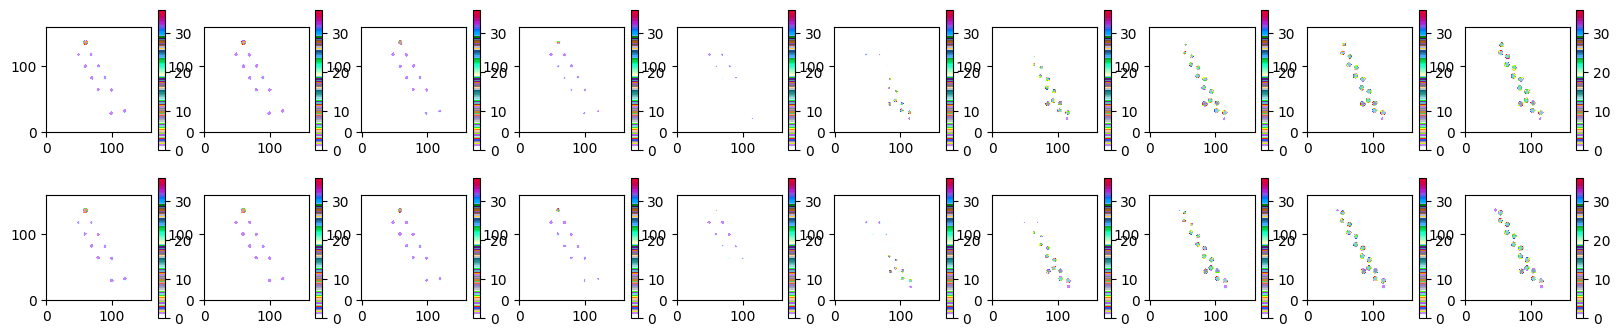

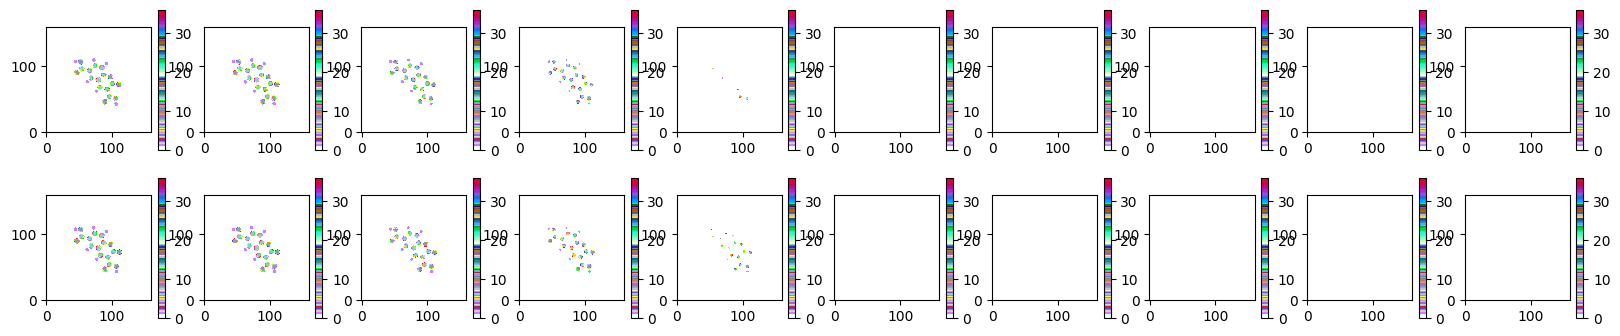

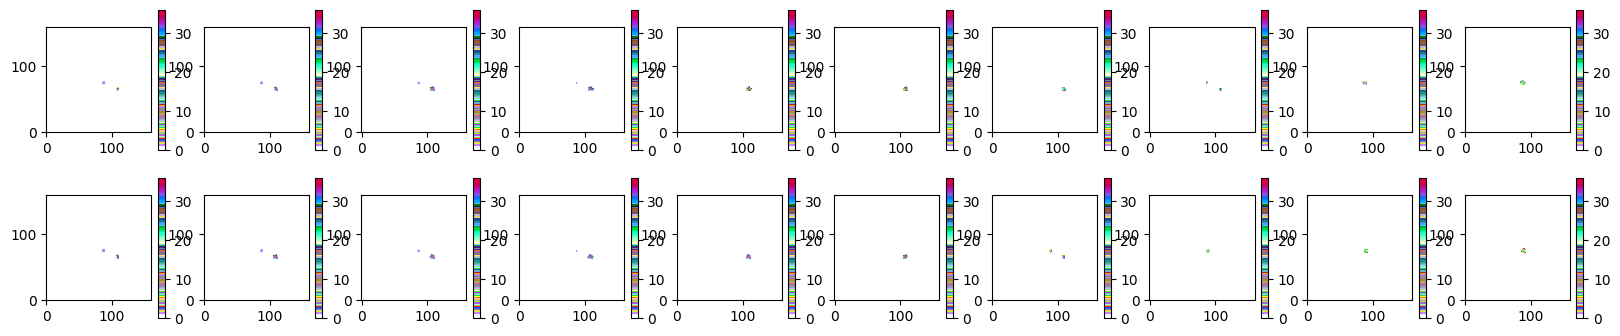

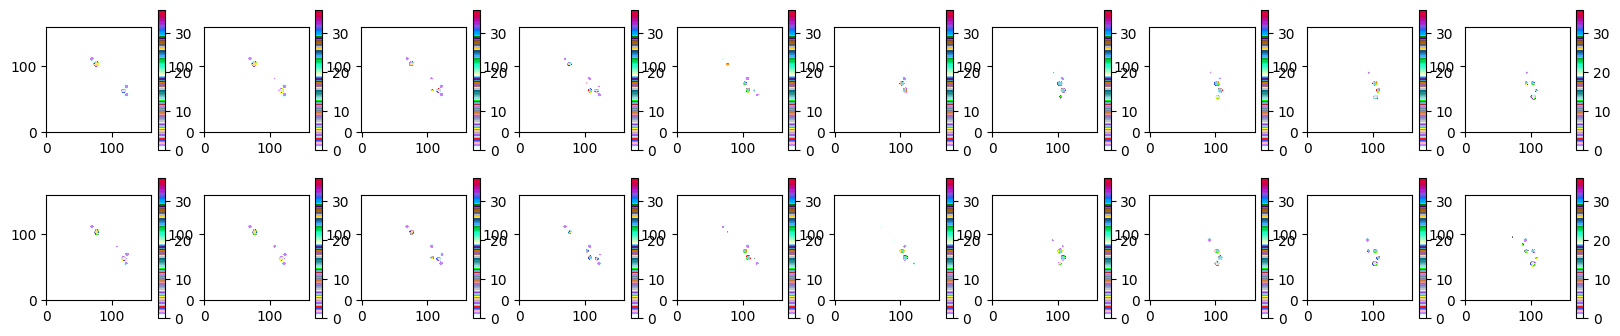

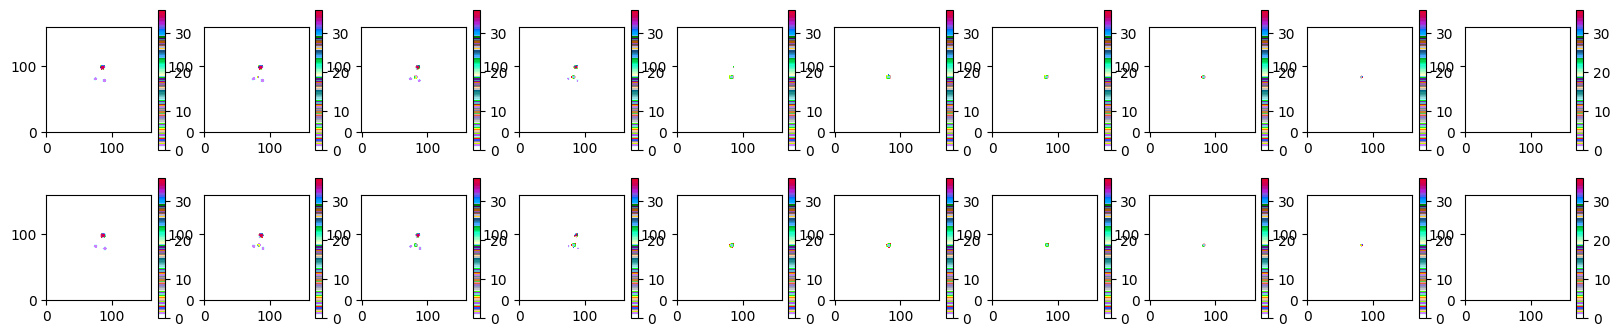

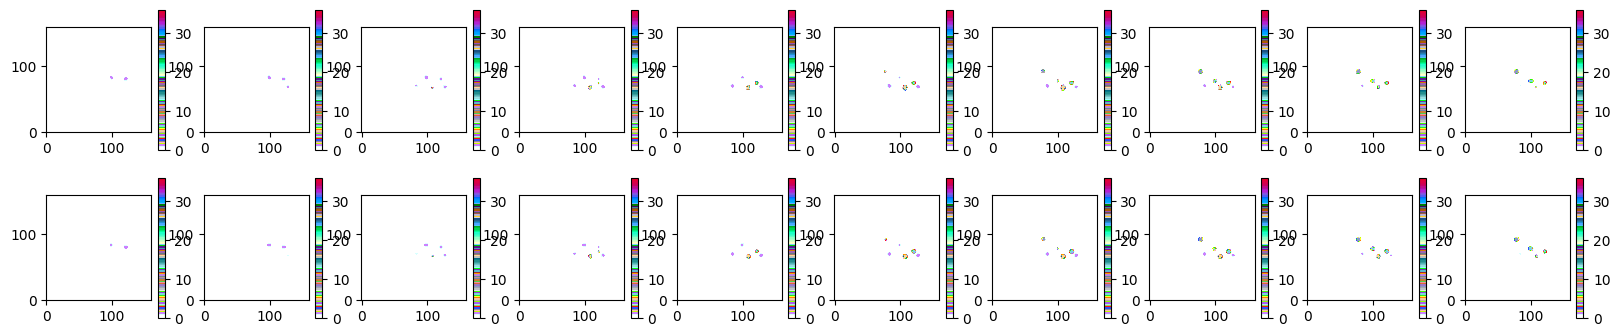

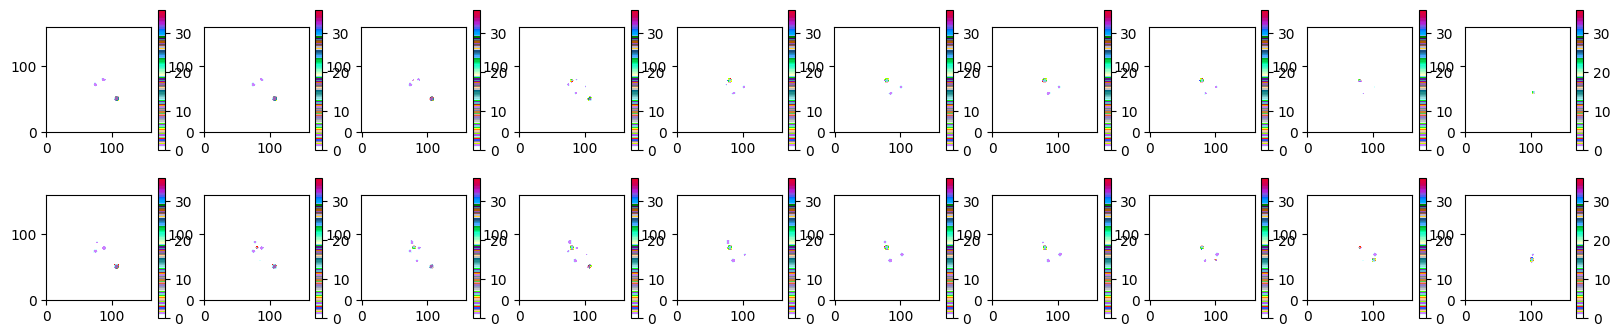

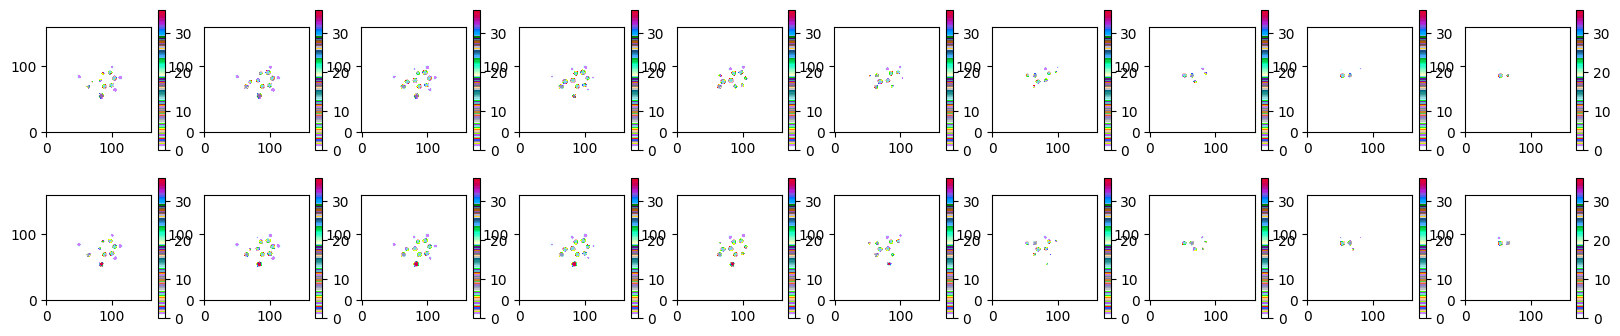

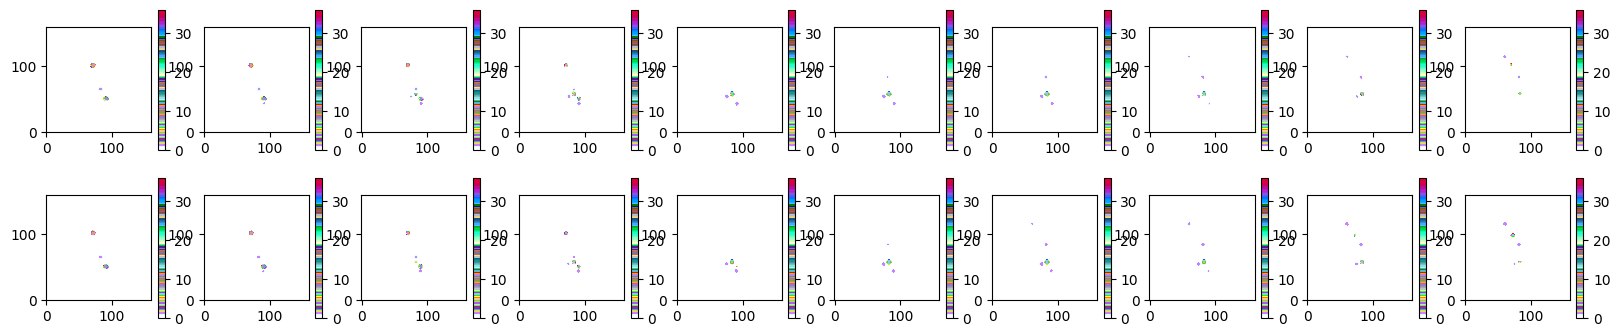

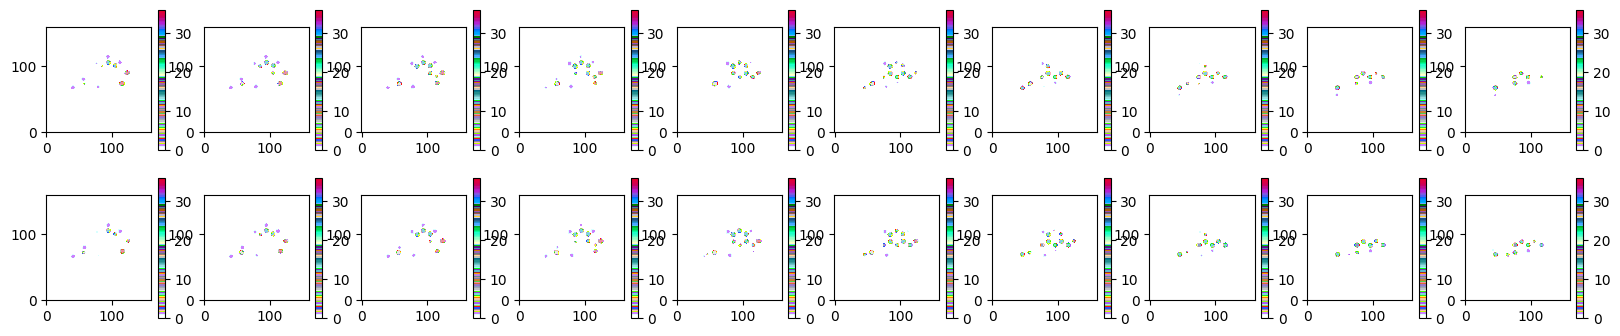

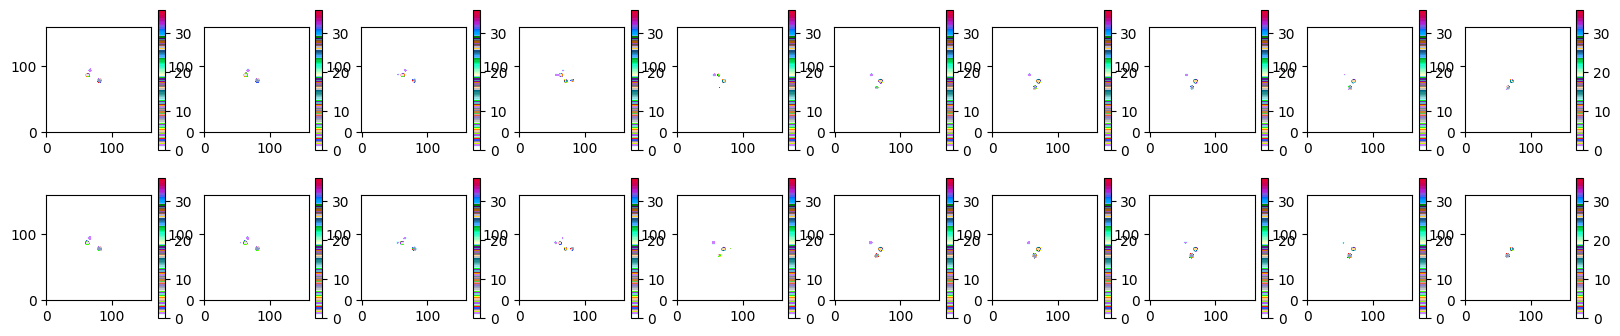

In [26]:
# Create a custom colormap, with white for the background
from matplotlib.colors import ListedColormap
import ase.data.colors
colors = ase.data.colors.jmol_colors
colors[0] = (1, 1, 1)

my_cmap = ListedColormap(colors)

for i in range(inputs.shape[0]):
    fig = plt.figure(figsize=(20, 4))
    pred_argmax = jnp.argmax(preds[i], axis=-1)
    for z in range(preds.shape[-2]):
        ax = plt.subplot(2, 10, z+1)
        im = ax.imshow(pred_argmax[..., z], cmap=my_cmap, origin='lower', vmin=0, vmax=36)
        plt.colorbar(im)

        ax = plt.subplot(2, 10, z+11)
        im = ax.imshow(targets[i, ..., z], cmap=my_cmap, origin='lower', vmin=0, vmax=36)
        plt.colorbar(im)
        

In [27]:
# Compute the dice score
def dice_score(
    pred: jnp.ndarray,
    target: jnp.ndarray,
    epsilon: float = 1e-8
) -> jnp.ndarray:
    intersection = jnp.sum(pred * target)
    union = jnp.sum(pred) + jnp.sum(target)
    return (2 * intersection + epsilon) / (union + epsilon)

dice_scores = []

for i in range(100):
    batch = next(ds)
    inputs, targets, preds, xyz = predict(state, batch)
    pred_argmax = jnp.argmax(preds, axis=-1)
    dice = dice_score(pred_argmax, targets)
    dice_scores.append(dice)

print(jnp.mean(jnp.array(dice_scores)))

9.428455


In [28]:
# Compute accuracy per class, i.e. argmax == target for each class in the target
def class_accuracy(
    pred: jnp.ndarray,
    target: jnp.ndarray
) -> jnp.ndarray:
    acc = []
    for i in range(1, 10):
        pred_class = pred == i
        target_class = target == i
        acc.append(jnp.mean(jnp.array(pred_class == target_class)))
    return jnp.array(acc)

class_accuracies = []

for i in range(100):
    batch = next(ds)
    inputs, targets, preds, xyz = predict(state, batch)
    pred_argmax = jnp.argmax(preds, axis=-1)
    class_acc = class_accuracy(pred_argmax, targets)
    class_accuracies.append(class_acc)

print(jnp.mean(jnp.array(class_accuracies), axis=0))

[0.9990524  1.         1.         1.         1.         0.9991098
 0.99981534 0.99980986 0.999922  ]


In [32]:
# Compute and plot confusion matrix
def confusion_matrix(
    pred: jnp.ndarray,
    target: jnp.ndarray
) -> jnp.ndarray:
    conf_matrix = np.zeros((36, 36))
    for i in range(0, 36):
        for j in range(0, 36):
            pred_class = pred == i
            target_class = target == j
            conf_matrix[i, j] = jnp.sum(pred_class * target_class)
    return conf_matrix

conf_matrices = []

for i in range(100):
    batch = next(ds)
    inputs, targets, preds, xyz = predict(state, batch)
    pred_argmax = jnp.argmax(preds, axis=-1)
    conf_matrix = confusion_matrix(pred_argmax, targets)
    conf_matrices.append(conf_matrix)

Text(120.72222222222221, 0.5, 'True')

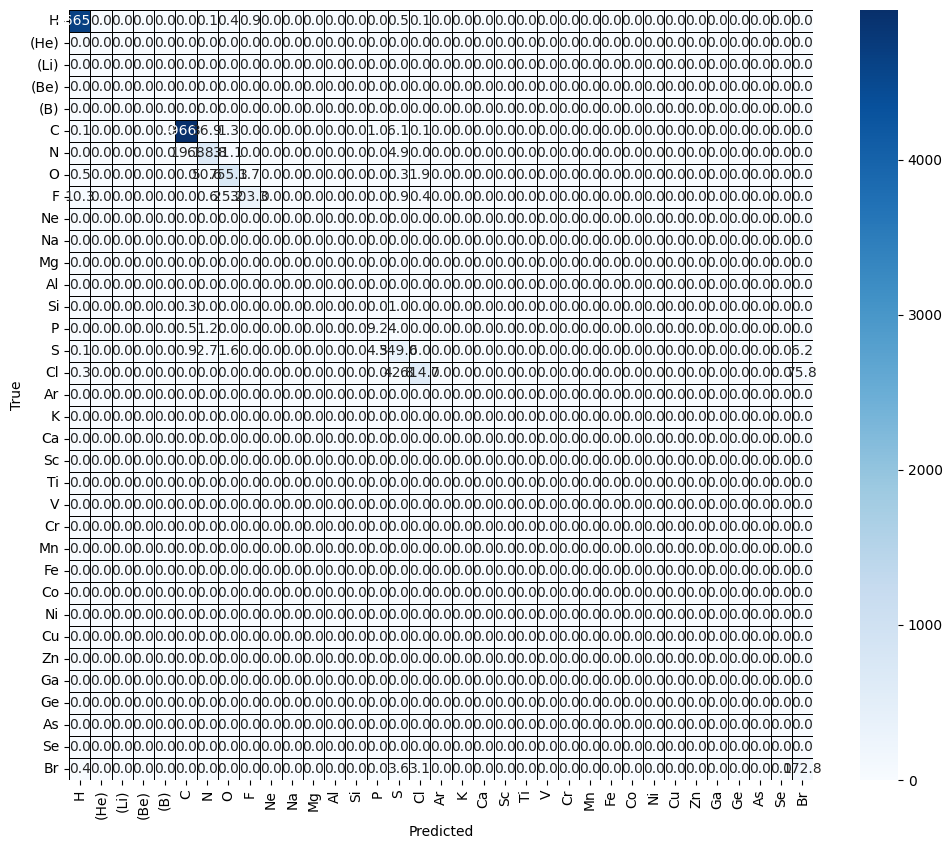

In [ ]:
conf_matrix = jnp.mean(jnp.array(conf_matrices), axis=0)

fig = plt.figure(figsize=(12, 10))
sns.heatmap(
    conf_matrix[1:, 1:],
    annot=True, fmt=".1f", cmap="Blues",
    linewidths=0.5, linecolor="black",
    xticklabels=[INDEX_TO_SYMBOL[i] for i in range(1, 36)],
    yticklabels=[INDEX_TO_SYMBOL[i] for i in range(1, 36)]
)
plt.xlabel("Predicted")
plt.ylabel("True")

Text(145.72222222222223, 0.5, 'True')

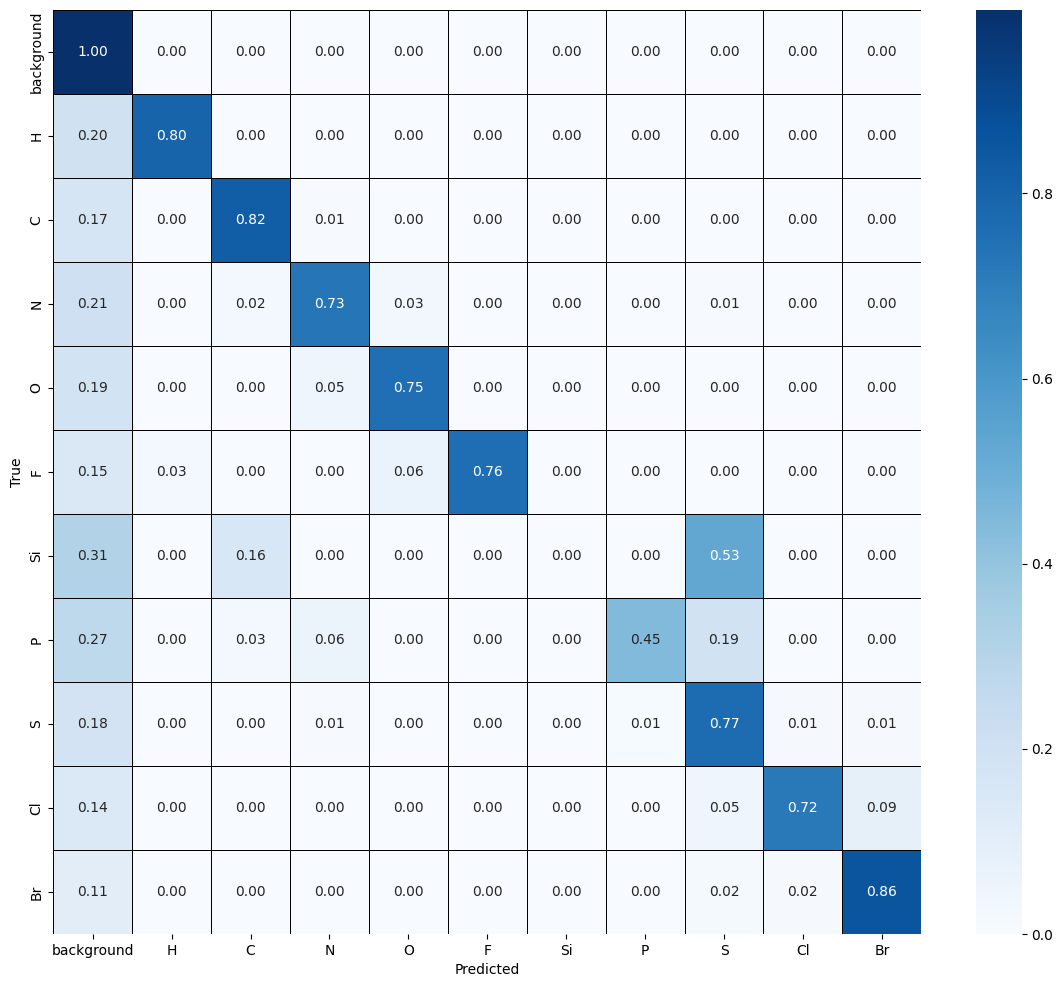

In [62]:
# show the confusion, normalize each row by the sum of the row
conf_matrix_norm = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)
# Drop rows and columns that have no entries
mask = conf_matrix_norm.sum(axis=1) > 0
conf_matrix_norm = conf_matrix_norm[mask][:, mask]

# Annotation matrix

fig = plt.figure(figsize=(14, 12))
sns.heatmap(
    conf_matrix_norm,
    annot=True,
    fmt=".2f", cmap="Blues",
    linewidths=0.5, linecolor="black",
    xticklabels=[INDEX_TO_SYMBOL_SHORT[i] for i in range(0, 11)],
    yticklabels=[INDEX_TO_SYMBOL_SHORT[i] for i in range(0, 11)]
)
plt.xlabel("Predicted")
plt.ylabel("True")

In [63]:
# Compute top-k accuracy
def top_k_accuracy(
    pred: jnp.ndarray,
    target: jnp.ndarray,
    k: int
) -> jnp.ndarray:
    top_k = jnp.argsort(pred, axis=-1)[..., -k:]
    top_k = jnp.sum(top_k == target[..., None], axis=-1)
    return jnp.mean(top_k)

top_k_accuracies = []

for i in range(100):
    batch = next(ds)
    inputs, targets, preds, xyz = predict(state, batch)
    top_k_acc = top_k_accuracy(preds, targets, 5)
    top_k_accuracies.append(top_k_acc)

In [ ]:
# Plot the top-5 accuracy as a confusion matrix
top_k_acc = jnp.mean(jnp.array(top_k_accuracies))

print(top_k_acc)

